# Demo 2: Controlled Pendulum
## Demo 2.8: Update SysSimX

- **Connections**

- **System**

- **Resolving Computational Causality**

- **System Graph Creation**

In [1]:
import sys
import numpy as np
from pathlib import Path

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))

**Generate FMUComponents**

In [2]:
from SysSimX.utilities.update_fmus import get_fmu_paths
from SysSimX.components.fmu_comp import FMUComponent

demo_dir_path = Path(repo_root / 'demos' / 'ControlledPendulum')
package_path = Path.cwd() / 'MyModels/Modelica/ControlledPendulum/'
fmu_output_dir = Path.cwd() / 'MyModels/FMUs/'
fmu_paths = get_fmu_paths(package_path, fmu_output_dir, force_rebuild=False)

fmu_paths


All FMUs for package 'ControlledPendulum' already exist. Skipping generation.


{'AngleEncoder': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/AngleEncoder.fmu'),
 'Demo_Driven': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Demo_Driven.fmu'),
 'Drive': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Drive.fmu'),
 'ImpactWall': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/ImpactWall.fmu'),
 'PID_Continuous': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/PID_Continuous.fmu'),
 'Pendulum': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Pendulum.fmu'),
 'PendulumWithWallContinuous': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/PendulumWithWallContinuous.fmu'),
 'Reference': PosixPath('/home/flo/repos/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Reference.fmu')}

In [3]:
ref          = FMUComponent(name='ref', fmu_path=fmu_paths['Reference'], group='Input')
sensor_ref   = FMUComponent(name='sensor_ref', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
sensor_state = FMUComponent(name='sensor_state', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
pid          = FMUComponent(name='pid', fmu_path=fmu_paths['PID_Continuous'], group='Control')
drive        = FMUComponent(name='drive', fmu_path=fmu_paths['Drive'], group='Actuator')
eqb_pendulum     = FMUComponent(name='EQB_Pendulum', fmu_path=fmu_paths['Pendulum'], group='Plant')

**Component Configuration**

In [4]:
# Reference trajectory
ref_freq = 0.5 # Hz
q_mean_deg = 0
q_ampl_deg = 10
ref_params ={}
ref_params['amplitude'] = np.deg2rad(q_ampl_deg)
ref_params['mean'] = np.deg2rad(q_mean_deg)
ref_params['frequency'] = ref_freq
ref.set_parameters(**ref_params)

# Sensor Configuration
nbits = 12
sensor_params = {}
sensor_params['q_max'] = np.deg2rad(q_mean_deg + q_ampl_deg)
sensor_params['q_min'] = np.deg2rad(q_mean_deg + q_ampl_deg)
sensor_ref.parameters['nBits'].start = nbits
sensor_ref.set_parameters(**sensor_params)
sensor_state.set_parameters(**sensor_params)

# PID Controller Configuration
pid_params = {}
pid_params['k'] = 10
pid_params['Ti'] = 0.5
pid_params['Td'] = 0.25
pid.set_parameters(**pid_params)

**Generate FEM and OpenSim Components**

In [5]:
from MyModels.FEM.fem_pendulum import FEMPendulum
from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum
from MyModels.pendulum_multi_comp import PendulumMultiComp

fem_pendulum = FEMPendulum("FEM_Pendulum", group="Plant")
opensim_pendulum = OpenSimPendulum("OpenSim_Pendulum", group="Plant")

pendulum = PendulumMultiComp(fem_comp=fem_pendulum,
                             opensim_comp=opensim_pendulum,
                             fmu_comp=eqb_pendulum)


**Simulation Parameters**

In [6]:
# Simulation parameters
t0, tf, h = 0, 10, 0.01
fem_pendulum.sim_params.t_end = tf
fem_pendulum.anim_params.animate = False

**Define Connections**

In [7]:
from SysSimX.system.connection import Connection

c1 = Connection(src_comp=ref.name, src_port=ref.output_specs['q_ref'].name,
                dst_comp=sensor_ref.name, dst_port=sensor_ref.input_specs['q'].name)

c2 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['q'].name,
                dst_comp=sensor_state.name, dst_port=sensor_state.input_specs['q'].name,
                delay=1)

c3 = Connection(src_comp=sensor_ref.name, src_port=sensor_ref.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['ref'].name)

c4 = Connection(src_comp=sensor_state.name, src_port=sensor_state.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['y'].name)

c5 = Connection(src_comp=pid.name, src_port=pid.output_specs['u'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['u_control'].name)

c6 = Connection(src_comp=drive.name, src_port=drive.output_specs['torque'].name,
                dst_comp=pendulum.name, dst_port=pendulum.input_specs['torque'].name)

c7 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['omega'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['omega'].name,
                delay=1)

connections = [c1, c2, c3, c4, c5, c6, c7]
components = [ref, sensor_ref, sensor_state, pid, drive, pendulum]

**Define System**

In [8]:
from SysSimX.system.system import System

system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

# Adding the same connection again to test validation
try:
    system.add_connection(c1)
except ValueError as e:
    print(f"Error: {e}")
system.compute_execution_order()

Error: Duplicate connection: ref.q_ref -> sensor_ref.q with delay 0


**Create System Graph**

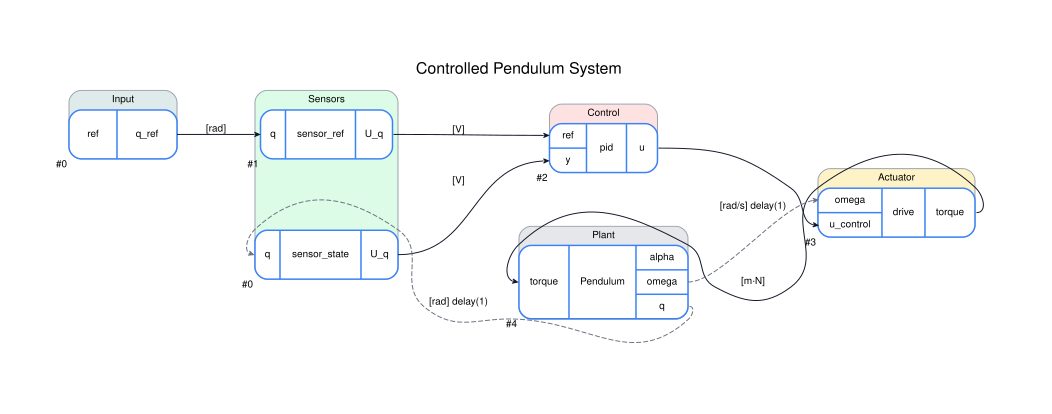

In [9]:
from SysSimX.viz.sysgraph import SystemGraphVisualizer
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()
visualizer.save("figures/demo-2-8_syssimx_system_graph.svg")

In [10]:
system.initialize(t0)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [11]:
system.run(t0, tf, h)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
------------------------------------------------------------
Switch from

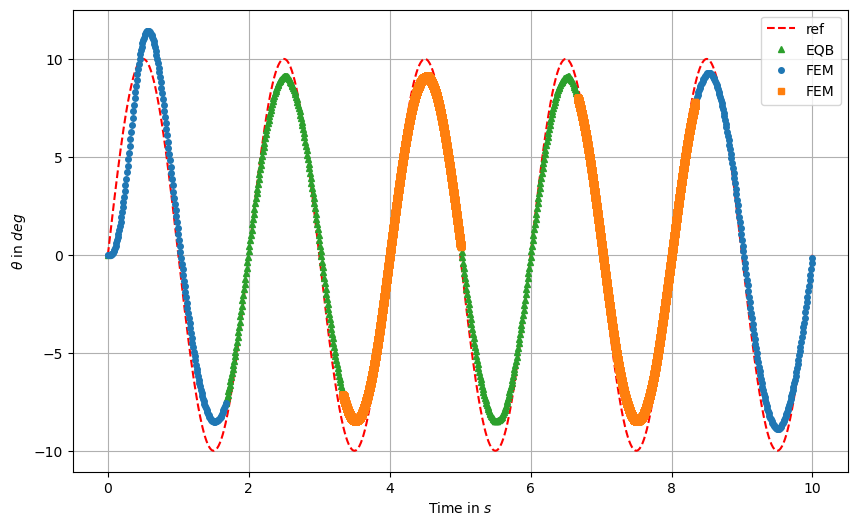

In [12]:
t_vals_ref, q_vals_ref = zip(*ref.outputs['q_ref'].history)

t_vals_eqb, q_vals_eqb = zip(*pendulum.models['EQB'].outputs['q'].history)
t_vals_fem, q_vals_fem = zip(*pendulum.models['FEM'].outputs['q'].history)
t_vals_os, q_vals_os = zip(*pendulum.models['OpenSim'].outputs['q'].history)

marker_size = 4
fem_style = {'color': 'C0', 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size}
opensim_style = {'color': 'C1', 'linestyle': 'None', 'marker': 's', 'markersize': marker_size}
eqb_style = {'color': 'C2', 'linestyle': 'None', 'marker': '^', 'markersize': marker_size}
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(t_vals_ref, np.rad2deg(q_vals_ref), label="ref", color='red', linestyle='--')
plt.plot(t_vals_eqb, np.rad2deg(q_vals_eqb), label='EQB', **eqb_style)
plt.plot(t_vals_fem, np.rad2deg(q_vals_fem), label='FEM', **fem_style)
plt.plot(t_vals_os, np.rad2deg(q_vals_os), label='FEM', **opensim_style)
plt.ylabel(r'$\theta$ in $deg$')
plt.xlabel('Time in $s$')
plt.grid()
plt.legend()
plt.show()

------------------------